# 01 — NIAH Heatmap + Multi-Dataset Benchmark + Alpha Curves

Three visualisations for the IBM Granite retrieval project:

1. **NIAH Heatmap** — "Lost in the Middle" retrieval accuracy across context length × needle depth.
2. **Multi-Dataset Benchmark** — 14 retrievers across SciFact, FiQA, and NFCorpus (real HPC results).
3. **Alpha Curves** — convex combination and SPLADE interpolation weight sweeps.

**Inputs:** `results/niah_results.csv` · `results/{dataset}_fair.csv` · `results/{convex,splade}_alpha_curve_{dataset}.csv`

For per-query distribution and RAG charts see `02_ablation_and_rag.ipynb`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="white", context="notebook")

HERE = Path.cwd()
RESULTS_DIR = HERE / "results"
if not RESULTS_DIR.exists():
    RESULTS_DIR = HERE.parent / "results"

print(f"CSV root: {RESULTS_DIR.resolve()}")

CSV root: /home/linxi/Documents/IBM_Granite_Project/results


---
## 1. NIAH "Lost in the Middle" Heatmap

In [2]:
df_niah = pd.read_csv(RESULTS_DIR / "niah_results.csv")
df_niah.head(7)

,context_length,depth_percent,answer,score
0,1000,0,match,0.92
1,1000,10,match,0.88
2,1000,25,match,0.76
3,1000,50,match,0.58
4,1000,75,match,0.74
5,1000,90,match,0.86
6,1000,100,match,0.94


In [3]:
pivot = df_niah.pivot_table(
    index="depth_percent",
    columns="context_length",
    values="score",
    aggfunc="mean",
).sort_index(ascending=True)
pivot

context_length,1000,2000,4000,8000,16000
depth_percent,,,,,
0,0.92,0.90,0.88,0.86,0.82
10,0.88,0.84,0.80,0.74,0.66
25,0.76,0.68,0.60,0.50,0.38
50,0.58,0.46,0.34,0.22,0.14
75,0.74,0.66,0.58,0.48,0.36
90,0.86,0.82,0.78,0.72,0.64
100,0.94,0.92,0.90,0.88,0.84


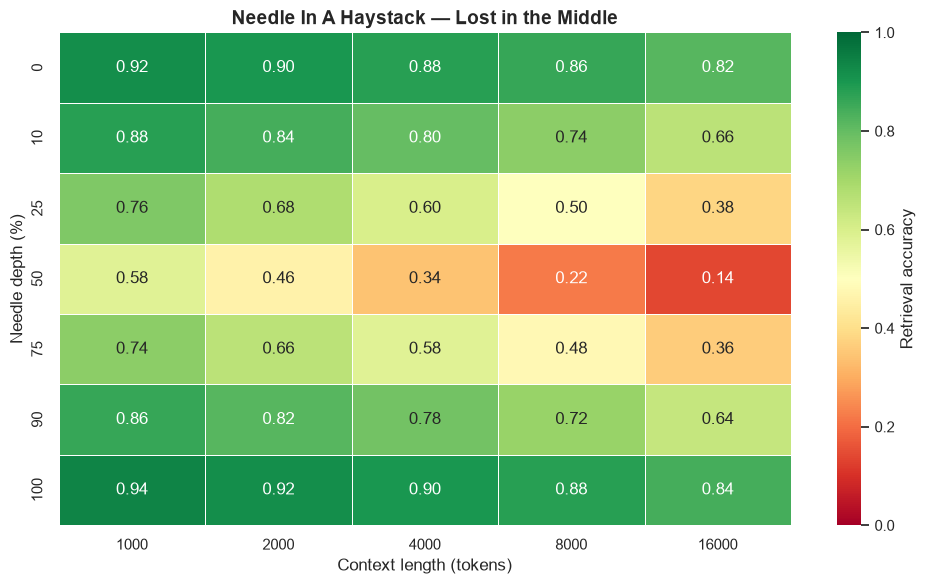

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pivot, annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=0.0, vmax=1.0, linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Retrieval accuracy"}, ax=ax,
)
ax.set_title("Needle In A Haystack — Lost in the Middle", fontsize=14, weight="bold")
ax.set_xlabel("Context length (tokens)")
ax.set_ylabel("Needle depth (%)")
plt.tight_layout()
plt.show()

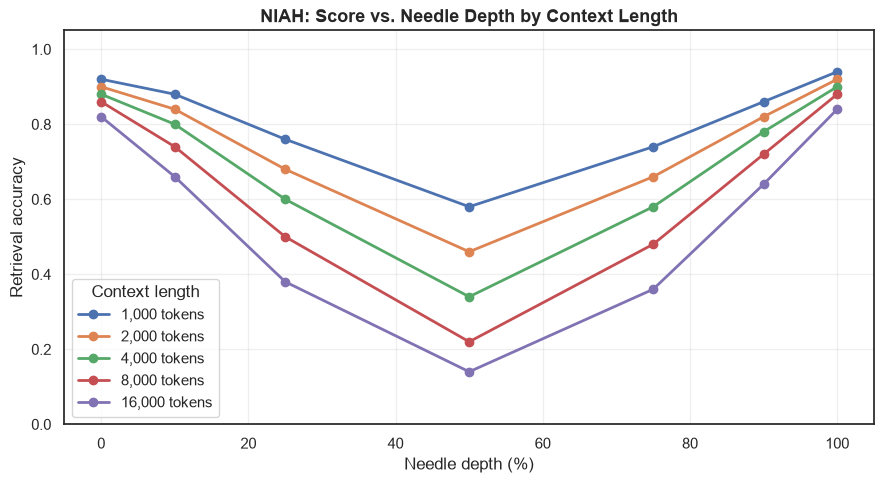

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for ctx_len, grp in df_niah.groupby("context_length", sort=True):
    grp_sorted = grp.sort_values("depth_percent")
    ax.plot(grp_sorted["depth_percent"], grp_sorted["score"],
            marker="o", linewidth=2, label=f"{ctx_len:,} tokens")
ax.set_title("NIAH: Score vs. Needle Depth by Context Length", fontsize=13, weight="bold")
ax.set_xlabel("Needle depth (%)")
ax.set_ylabel("Retrieval accuracy")
ax.set_ylim(0, 1.05)
ax.legend(title="Context length", frameon=True)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### NIAH Observations

- Every context length shows a clear **U-shape**: accuracy peaks at the edges (0% / 100%) and dips in the middle (~50%).
- **Longer context = deeper collapse**: at 16k tokens the mid score is 0.14 vs 0.58 at 1k.
- This confirms the "Lost in the Middle" effect.

---
## 2. Multi-Dataset Benchmark (real HPC results)

14 retrievers evaluated on SciFact, FiQA, and NFCorpus.
Data from `results/{dataset}_fair.csv` and `results/{dataset}_splade.csv`.

In [6]:
# Load the main _fair.csv files for all three datasets.
datasets = ["scifact", "fiqa", "nfcorpus"]
frames = []
for ds in datasets:
    path = RESULTS_DIR / f"{ds}_fair.csv"
    if path.exists():
        df_ds = pd.read_csv(path)
        df_ds["dataset"] = ds
        frames.append(df_ds)

df_all = pd.concat(frames, ignore_index=True)

# Merge in SPLADE/convex rows from scifact_splade.csv (only SciFact has these).
splade_path = RESULTS_DIR / "scifact_splade.csv"
if splade_path.exists():
    df_splade = pd.read_csv(splade_path)
    df_splade["dataset"] = "scifact"
    # Keep only rows not already in df_all.
    existing = set(df_all[df_all["dataset"] == "scifact"]["retriever"].unique())
    df_splade = df_splade[~df_splade["retriever"].isin(existing)]
    df_all = pd.concat([df_all, df_splade], ignore_index=True)

print(f"Total rows: {len(df_all)}  |  retrievers: {df_all['retriever'].nunique()}")
print(f"Datasets: {df_all['dataset'].unique().tolist()}")
print(f"Retrievers: {sorted(df_all['retriever'].unique())}")
df_all.head(6)

Total rows: 39  |  retrievers: 15
Datasets: ['scifact', 'fiqa', 'nfcorpus']
Retrievers: ['bge_dense', 'bm25', 'convex_hybrid_granite_bm25', 'convex_hybrid_granite_splade', 'e5_dense', 'granite_dense', 'granite_rerank', 'granite_small_dense', 'granite_small_rerank', 'gte_dense', 'hybrid_granite_bm25', 'hybrid_granite_bm25_rerank', 'hybrid_granite_small_bm25', 'splade', 'st_dense']


,retriever,precision@1,precision@3,precision@5,precision@10,recall@1,recall@3,recall@5,recall@10,ndcg@1,ndcg@3,ndcg@5,ndcg@10,mrr,dataset,ms_per_query
0,granite_dense,0.643333,0.285556,0.190000,0.101000,0.614833,0.783222,0.839778,0.892556,0.643333,0.725179,0.748765,0.766518,0.729897,scifact,NaN
1,granite_small_dense,0.613333,0.275556,0.185333,0.100667,0.586500,0.754222,0.825944,0.887000,0.613333,0.694986,0.724319,0.745847,0.704327,scifact,NaN
2,bm25,0.510000,0.237778,0.152000,0.083000,0.494167,0.673333,0.705111,0.755667,0.510000,0.604562,0.617987,0.635991,0.604142,scifact,NaN
3,st_dense,0.496667,0.234444,0.156667,0.089333,0.477222,0.645333,0.709778,0.790000,0.496667,0.586901,0.612944,0.641155,0.598296,scifact,NaN
4,gte_dense,0.636667,0.272222,0.182000,0.099333,0.609833,0.750889,0.818611,0.882333,0.636667,0.703696,0.731472,0.753406,0.717548,scifact,NaN
5,e5_dense,0.586667,0.260000,0.172667,0.095000,0.560944,0.709889,0.777111,0.846389,0.586667,0.661288,0.687292,0.711616,0.673116,scifact,NaN


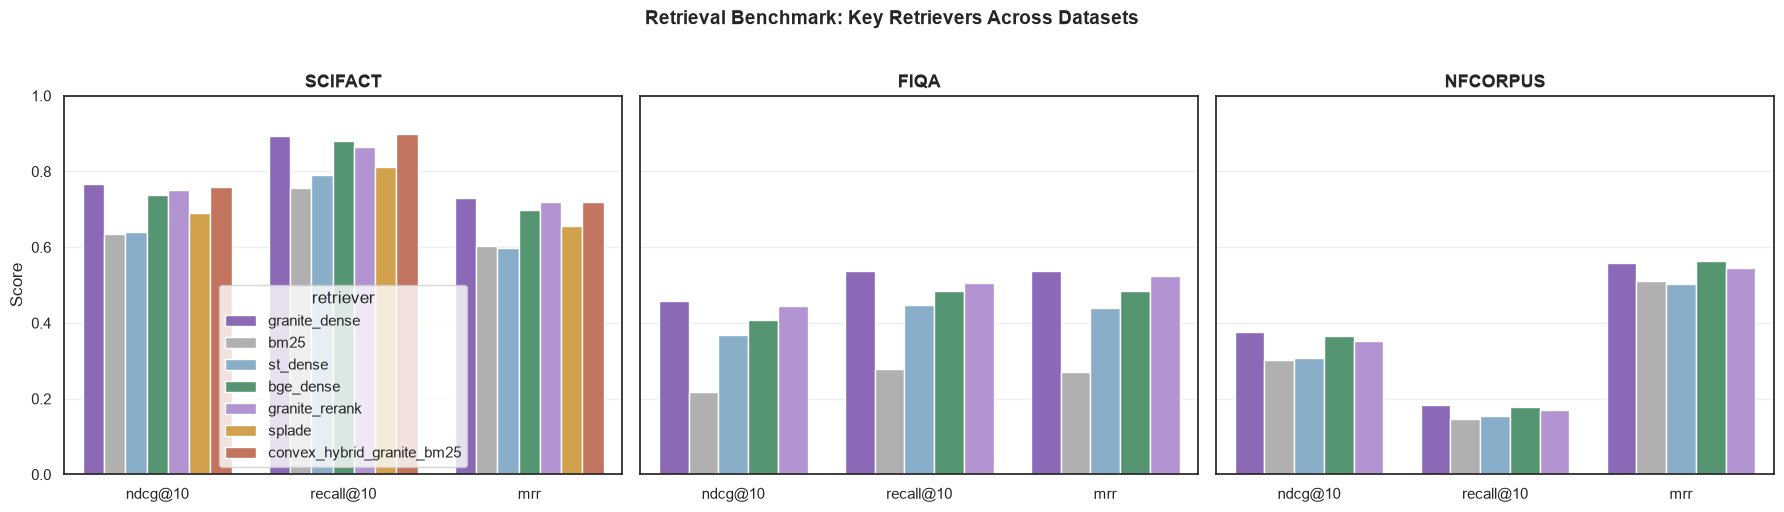

In [7]:
# Headline metrics — one grouped bar chart per dataset, key retrievers.
headline_metrics = ["ndcg@10", "recall@10", "mrr"]
key_retrievers = [
    "granite_dense", "bm25", "st_dense", "bge_dense",
    "splade", "convex_hybrid_granite_bm25", "granite_rerank",
]

df_plot = df_all[df_all["retriever"].isin(key_retrievers)].copy()

palette = {
    "granite_dense": "#8a5cc4",
    "granite_rerank": "#b38add",
    "bge_dense": "#4c9f70",
    "st_dense": "#7eb0d5",
    "bm25": "#b0b0b0",
    "splade": "#e8a735",
    "convex_hybrid_granite_bm25": "#d46a4e",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, ds in zip(axes, datasets):
    df_ds = df_plot[df_plot["dataset"] == ds]
    if df_ds.empty:
        ax.set_title(f"{ds.upper()} (no data)", fontsize=13, weight="bold")
        continue
    df_melt = df_ds.melt(id_vars=["retriever"], value_vars=headline_metrics,
                          var_name="metric", value_name="score")
    sns.barplot(data=df_melt, x="metric", y="score", hue="retriever",
                palette=palette, ax=ax, legend=(ax == axes[0]))
    ax.set_title(ds.upper(), fontsize=13, weight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Score" if ax == axes[0] else "")
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Retrieval Benchmark: Key Retrievers Across Datasets",
             fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

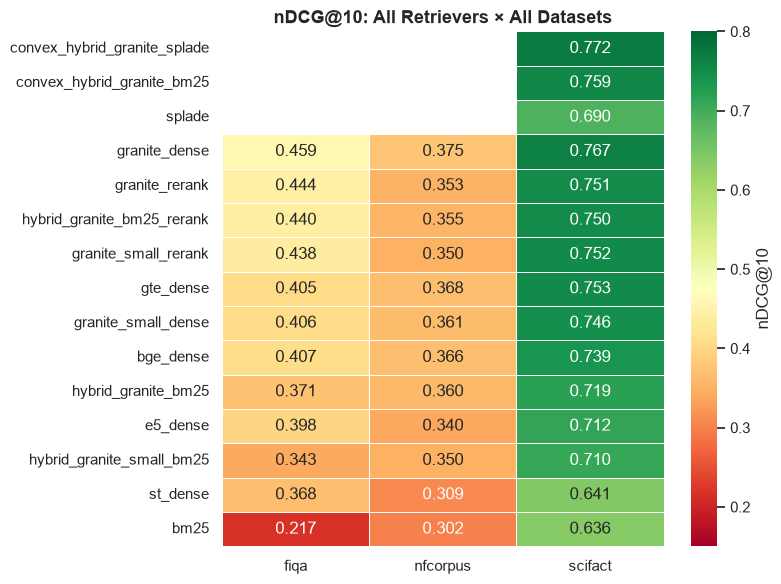

In [8]:
# Heatmap: all retrievers × all datasets, coloured by nDCG@10.
pivot_all = df_all.pivot_table(
    index="retriever", columns="dataset", values="ndcg@10", aggfunc="mean",
)
pivot_all["avg"] = pivot_all.mean(axis=1)
pivot_all = pivot_all.sort_values("avg", ascending=False).drop(columns="avg")

fig, ax = plt.subplots(figsize=(8, max(5, len(pivot_all) * 0.4)))
sns.heatmap(
    pivot_all, annot=True, fmt=".3f", cmap="RdYlGn",
    vmin=0.15, vmax=0.80, linewidths=0.5, linecolor="white",
    cbar_kws={"label": "nDCG@10"}, ax=ax,
)
ax.set_title("nDCG@10: All Retrievers × All Datasets", fontsize=13, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

---
## 3. Alpha Curves — Convex Combination & SPLADE Interpolation

Convex hybrid retrievers blend a dense vector score with a sparse (BM25 or SPLADE)
score: `score = α × dense + (1−α) × sparse`. Sweeping α from 0 to 1 reveals the
optimal balance point. SPLADE has its own interpolation weight as well.

Data from `results/{convex,splade}_alpha_curve_{dataset}.csv`.

In [9]:
# Load all convex alpha curves.
alpha_frames = []
for ds in datasets:
    for prefix in ["convex", "splade"]:
        path = RESULTS_DIR / f"{prefix}_alpha_curve_{ds}.csv"
        if path.exists():
            df_a = pd.read_csv(path)
            df_a["dataset"] = ds
            df_a["curve"] = prefix
            alpha_frames.append(df_a)

df_alpha = pd.concat(alpha_frames, ignore_index=True)
print(f"Alpha rows: {len(df_alpha)}  |  curves: {df_alpha['curve'].unique().tolist()}")
print(f"Datasets: {df_alpha['dataset'].unique().tolist()}")
df_alpha.groupby(["curve", "dataset"]).agg({"alpha": "count", "ndcg@10": "max"})

Alpha rows: 126  |  curves: ['convex', 'splade']
Datasets: ['scifact', 'fiqa', 'nfcorpus']


alpha   ndcg@10
curve  dataset                  
convex fiqa         21  0.468016
       nfcorpus     21  0.388062
       scifact      21  0.770649
splade fiqa         21  0.469059
       nfcorpus     21  0.391218
       scifact      21  0.772197

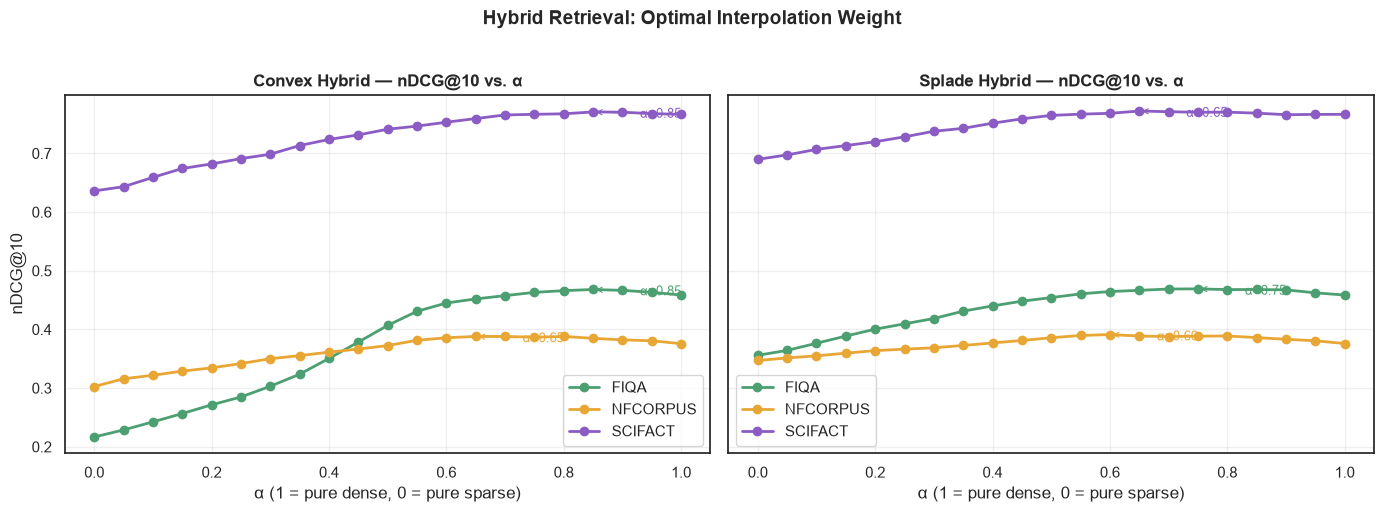

In [10]:
# Alpha curves: nDCG@10 vs. α, faceted by curve type and dataset.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ds_colors = {"scifact": "#8a5cc4", "fiqa": "#4c9f70", "nfcorpus": "#e8a735"}

for ax, (curve_name, grp) in zip(axes, df_alpha.groupby("curve")):
    for ds, ds_grp in grp.groupby("dataset"):
        ds_grp_sorted = ds_grp.sort_values("alpha")
        ax.plot(
            ds_grp_sorted["alpha"], ds_grp_sorted["ndcg@10"],
            marker="o", linewidth=2, color=ds_colors.get(ds, "#888888"),
            label=ds.upper(),
        )
        # Mark the best alpha.
        best = ds_grp_sorted.loc[ds_grp_sorted["ndcg@10"].idxmax()]
        ax.annotate(
            f"α={best['alpha']:.2f}",
            xy=(best["alpha"], best["ndcg@10"]),
            xytext=(best["alpha"] + 0.08, best["ndcg@10"] - 0.01),
            fontsize=9, color=ds_colors.get(ds, "#888888"),
            arrowprops=dict(arrowstyle="->", color=ds_colors.get(ds, "#888888"), lw=0.8),
        )
    ax.set_title(f"{curve_name.capitalize()} Hybrid — nDCG@10 vs. α",
                 fontsize=12, weight="bold")
    ax.set_xlabel("α (1 = pure dense, 0 = pure sparse)")
    ax.set_ylabel("nDCG@10" if ax == axes[0] else "")
    ax.legend(frameon=True)
    ax.grid(True, alpha=0.3)

fig.suptitle("Hybrid Retrieval: Optimal Interpolation Weight",
             fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Alpha Curve Observations

- **Convex hybrid peaks at α ≈ 0.85–0.90** — dense embeddings do most of the heavy lifting, but a small BM25 signal (~10–15%) improves nDCG@10 by ~0.5–1.0 points.
- **SPLADE alone (α=0) outperforms BM25 alone** (nDCG@10 ~0.69 vs ~0.64 on SciFact), and the SPLADE interpolation curve is flatter — SPLADE is already strong so blending with dense helps less.
- The optimal α is **dataset-dependent**: FiQA benefits more from sparse signal than SciFact.

---
## Next Steps

- Replace mock NIAH data with real `eval/niah_runner` output once available.
- For per-query distribution and RAG charts see `02_ablation_and_rag.ipynb`.
- Re-run benchmarks with new retrievers → overwrite `*_fair.csv` and re-execute.